# Import statements

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# EDA

#### Read the data

In [2]:
data = pd.read_excel("Online Retail.xlsx")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Checking for nulls

In [3]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


#### Checking for duplicates

In [6]:
data.duplicated().sum()

np.int64(5268)

#### Remove missing customer IDs

In [19]:
df = data.dropna(subset=["CustomerID"])

#### Remove returns and zero UnitPrice rows

In [35]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

#### Adding a column that shows the total value of purchase made

In [36]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# Creating the RFM table

#### Determine the reference date

In [37]:
reference_date = df["InvoiceDate"].max()
reference_date

Timestamp('2011-12-09 12:50:00')

In [38]:
# Build RFM table
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": "max",
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

# Reset_index
rfm = rfm.reset_index()

# Rename columns
rfm.columns = ["CustomerID", "LastPurchaseDate", "Frequency", "Monetary"]

# Calculate recency
rfm["Recency"] = (reference_date - rfm["LastPurchaseDate"]).dt.days

# Drop temporary column
rfm = rfm.drop(columns=["LastPurchaseDate"])

# Reorder columns
rfm = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]]
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


#### Log transform Frequency and Monetary

In [39]:
rfm["LogFrequency"] = np.log1p(rfm["Frequency"])
rfm["LogMonetary"] = np.log1p(rfm["Monetary"])

#### Scale the features

In [42]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(rfm[["Recency", "LogFrequency", "LogMonetary"]])
scaled_features

array([[ 2.33457414, -0.95521426,  3.70622476],
       [-0.90534032,  1.07442519,  1.41184341],
       [-0.17535959,  0.38630445,  0.7164889 ],
       ...,
       [-0.8453419 , -0.36158278, -1.11812113],
       [-0.88534085,  2.17800394,  0.83829669],
       [-0.49535114,  0.05960547,  0.73400231]], shape=(4338, 3))

In [47]:
rfm_scaled = pd.DataFrame(
    scaled_features, 
    columns=["Recency", "LogFrequency", "LogMonetary"], 
    index=rfm["CustomerID"])
rfm_scaled.head()

,Recency,LogFrequency,LogMonetary
CustomerID,,,
12346.0,2.334574,-0.955214,3.706225
12347.0,-0.905340,1.074425,1.411843
12348.0,-0.175360,0.386304,0.716489
12349.0,-0.735345,-0.955214,0.698739
12350.0,2.174578,-0.955214,-0.618962


# The Elbow Method

In [52]:
inertia_values = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia_values.append(kmeans.inertia_)

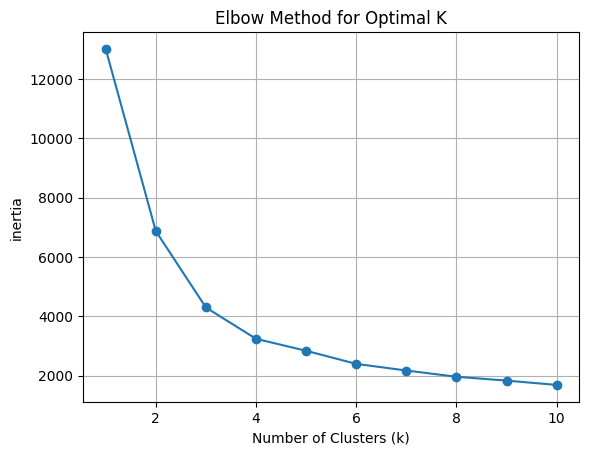

In [55]:
plt.plot(range(1,11), inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

In [67]:
print("4 appears to be the optimal k")

4 appears to be the optimal k


#### The K-Means model

In [78]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)
clusters

array([1, 3, 1, ..., 0, 3, 1], shape=(4338,), dtype=int32)

In [79]:
rfm["Cluster"] = clusters
rfm.head()

,CustomerID,Recency,Frequency,Monetary,LogFrequency,LogMonetary,Cluster
0,12346.0,325,1,77183.60,0.693147,11.253955,1
1,12347.0,1,7,4310.00,2.079442,8.368925,3
2,12348.0,74,4,1797.24,1.609438,7.494564,1
3,12349.0,18,1,1757.55,0.693147,7.472245,1
4,12350.0,309,1,334.40,0.693147,5.815324,2


#### The Profile Table

In [80]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cluster_profile = cluster_profile.sort_values("Monetary", ascending=False)
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
3,18.785838,15.734024,9735.643316
1,45.218772,4.182195,1645.456959
2,258.513340,1.370331,387.046734
0,57.144210,1.513474,384.224691


# Visualization

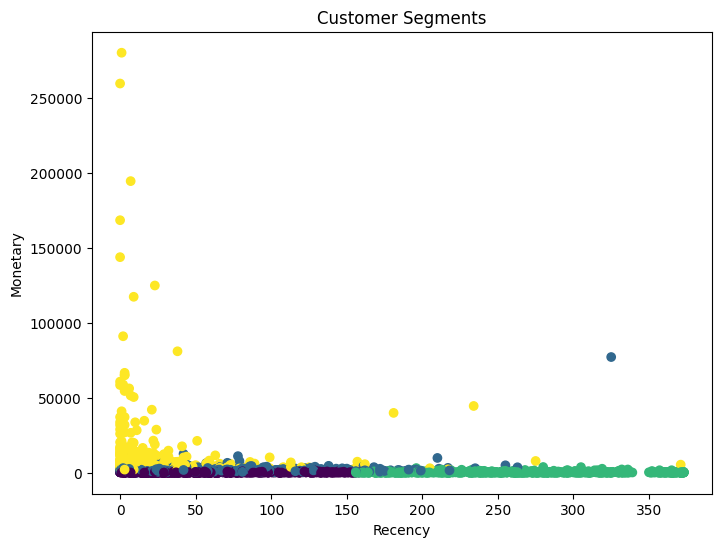

In [81]:
plt.figure(figsize=(8,6))
plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments")
plt.show()

#### Export the clusters data

In [82]:
rfm.to_csv("rfm_clusters.csv", index=False)